First 5 Records:
   Student_ID  Study_Hours  Attendance  Assignment_Score  Final_Marks
0           1            7          71                61        68.45
1           2            4          93                50        69.50
2           3            8          92                87        81.65
3           4            5          82                55        60.75
4           5            7          83                72        70.15

Dataset Shape:
(100, 5)

Missing Values:
Student_ID          0
Study_Hours         0
Attendance          0
Assignment_Score    0
Final_Marks         0
dtype: int64

Missing Values After Introduction:
Student_ID          0
Study_Hours         1
Attendance          1
Assignment_Score    1
Final_Marks         0
dtype: int64

Missing Values After Handling:
Student_ID          0
Study_Hours         0
Attendance          0
Assignment_Score    0
Final_Marks         0
dtype: int64

Descriptive Statistics:
       Student_ID  Study_Hours  Attendance  Assignment_Scor

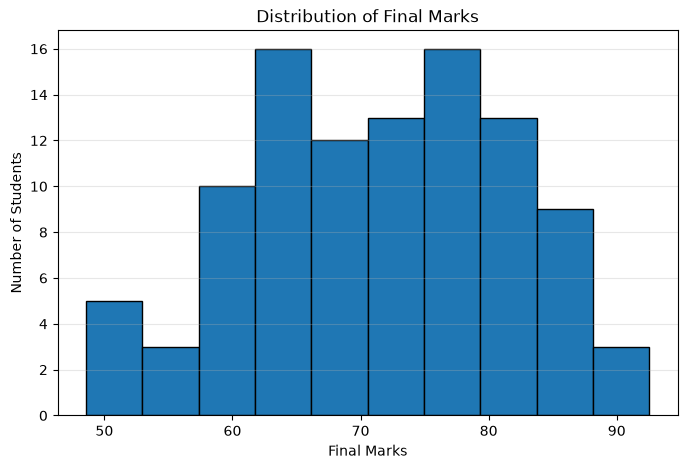

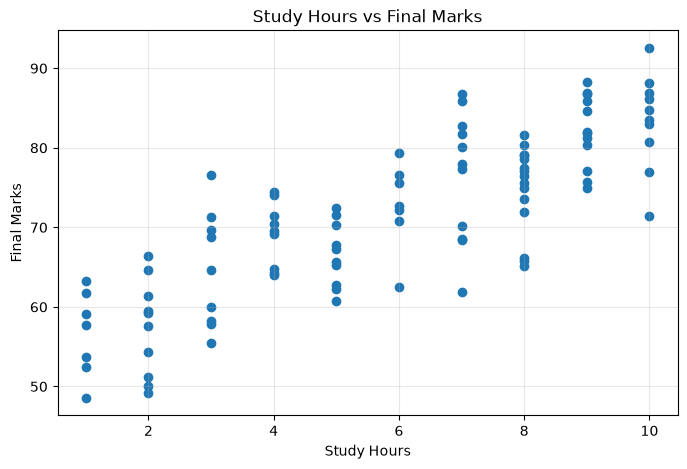

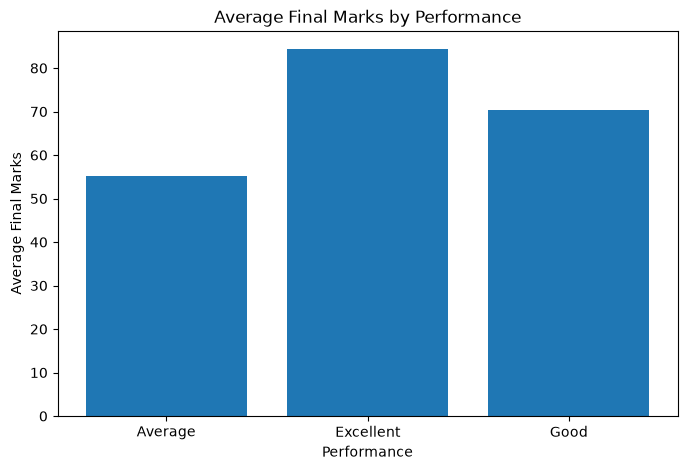

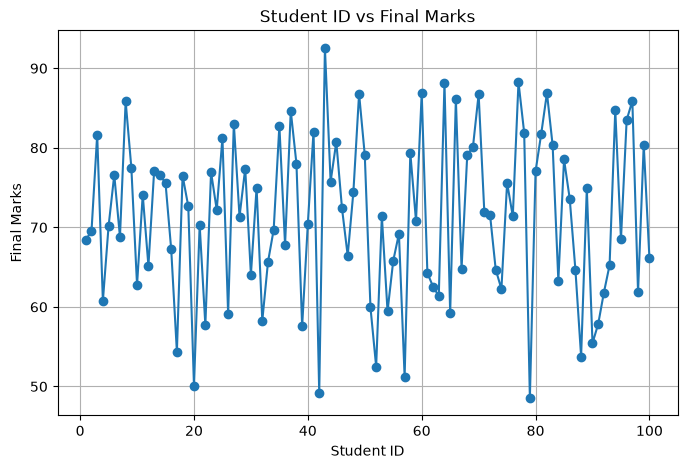

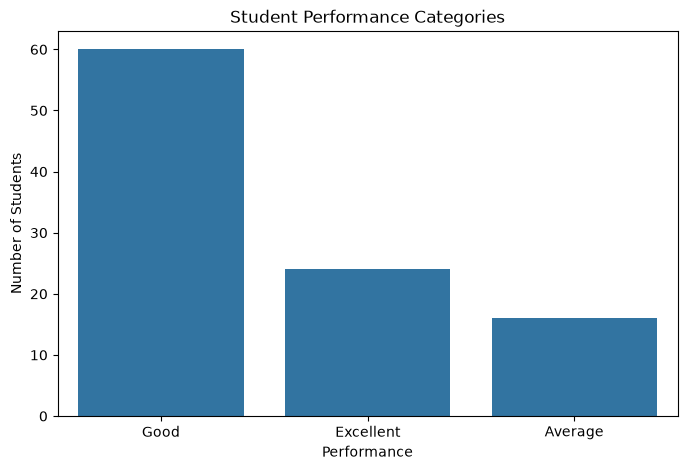


Correlation Matrix:
                  Study_Hours  Attendance  Assignment_Score  Final_Marks
Study_Hours          1.000000   -0.141530         -0.022033     0.820862
Attendance          -0.141530    1.000000          0.045448     0.214376
Assignment_Score    -0.022033    0.045448          1.000000     0.309928
Final_Marks          0.820862    0.214376          0.309928     1.000000


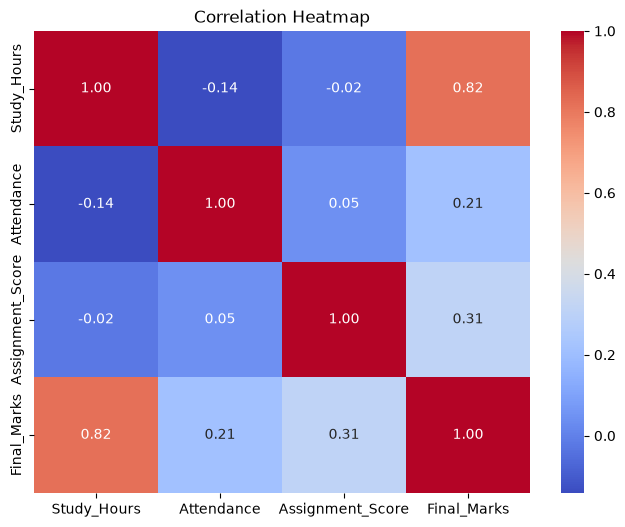

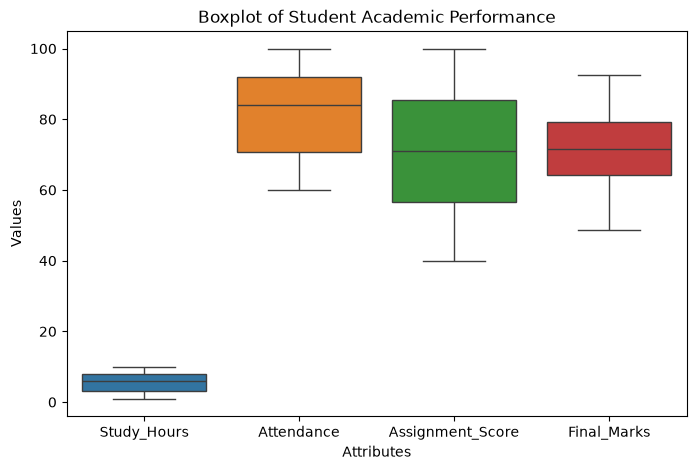


========== PROJECT SUMMARY ==========
Total Students: 100
Average Final Marks: 71.35
Highest Final Marks: 92.55
Lowest Final Marks: 48.55

Performance Summary:
Performance
Good         60
Excellent    24
Average      16
Name: count, dtype: int64

Project Analysis Completed Successfully!


In [8]:
# STUDENT ACADEMIC PERFORMANCE ANALYSIS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("studentperformance.csv")

print("First 5 Records:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())


df.loc[5, "Study_Hours"] = np.nan
df.loc[15, "Attendance"] = np.nan
df.loc[25, "Assignment_Score"] = np.nan

print("\nMissing Values After Introduction:")
print(df.isnull().sum())

# Fill missing values using median
df["Study_Hours"] = df["Study_Hours"].fillna(
    df["Study_Hours"].median()
)

df["Attendance"] = df["Attendance"].fillna(
    df["Attendance"].median()
)

df["Assignment_Score"] = df["Assignment_Score"].fillna(
    df["Assignment_Score"].median()
)

print("\nMissing Values After Handling:")
print(df.isnull().sum())



print("\nDescriptive Statistics:")
print(df.describe())

print("\nAverage Study Hours:",
      round(df["Study_Hours"].mean(), 2))

print("Average Attendance:",
      round(df["Attendance"].mean(), 2))

print("Average Assignment Score:",
      round(df["Assignment_Score"].mean(), 2))

print("Average Final Marks:",
      round(df["Final_Marks"].mean(), 2))


def performance(marks):
    if marks >= 80:
        return "Excellent"
    elif marks >= 60:
        return "Good"
    elif marks >= 40:
        return "Average"
    else:
        return "Needs Improvement"

df["Performance"] = df["Final_Marks"].apply(performance)

print("\nPerformance Categories:")
print(df["Performance"].value_counts())



top_students = df.sort_values(
    by="Final_Marks",
    ascending=False
).head(10)

print("\nTop 10 Students:")
print(top_students[
    ["Student_ID", "Study_Hours",
     "Attendance", "Assignment_Score",
     "Final_Marks"]
])

# HISTOGRAM

plt.figure(figsize=(8, 5))

plt.hist(
    df["Final_Marks"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Final Marks")
plt.xlabel("Final Marks")
plt.ylabel("Number of Students")
plt.grid(axis="y", alpha=0.3)
plt.savefig("histstudent.png")
plt.show()

# SCATTER PLOT

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Study_Hours"],
    df["Final_Marks"]
)

plt.title("Study Hours vs Final Marks")
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.grid(True, alpha=0.3)
plt.savefig("Scatterstudent.png")
plt.show()

# BAR PLOT

avg_marks = df.groupby("Performance")["Final_Marks"].mean()

plt.figure(figsize=(8, 5))

plt.bar(avg_marks.index, avg_marks.values)

plt.title("Average Final Marks by Performance")
plt.xlabel("Performance")
plt.ylabel("Average Final Marks")
plt.savefig("barstudent.png")
plt.show()

# LINE PLOT 

plt.figure(figsize=(8, 5))

plt.plot(
    df["Student_ID"],
    df["Final_Marks"],
    marker="o"
)

plt.title("Student ID vs Final Marks")
plt.xlabel("Student ID")
plt.ylabel("Final Marks")
plt.grid(True)
plt.savefig("lineplotstudent")
plt.show()



# COUNT PLOT

plt.figure(figsize=(8, 5))

sns.countplot(
    x="Performance",
    data=df
)

plt.title("Student Performance Categories")
plt.xlabel("Performance")
plt.ylabel("Number of Students")
plt.savefig("countplotstudent")
plt.show()



correlation = df[
    ["Study_Hours",
     "Attendance",
     "Assignment_Score",
     "Final_Marks"]
].corr()

print("\nCorrelation Matrix:")
print(correlation)

# CORRELATION HEATMAP

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("heatmap.png")

plt.show()

# BOX PLOT

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df[
        ["Study_Hours",
         "Attendance",
         "Assignment_Score",
         "Final_Marks"]
    ]
)

plt.title("Boxplot of Student Academic Performance")
plt.xlabel("Attributes")
plt.ylabel("Values")
plt.savefig("boxplotstudent")
plt.show()


# FINAL SUMMARY

print("\n========== PROJECT SUMMARY ==========")

print("Total Students:", len(df))

print("Average Final Marks:",
      round(df["Final_Marks"].mean(), 2))

print("Highest Final Marks:",
      round(df["Final_Marks"].max(), 2))

print("Lowest Final Marks:",
      round(df["Final_Marks"].min(), 2))

print("\nPerformance Summary:")
print(df["Performance"].value_counts())

print("\nProject Analysis Completed Successfully!")